In [5]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

from seqAE_model import SeqAutoencoder
from contra_seq_dataset import AnchoredSampler
from torch.utils.data import DataLoader, RandomSampler
from contra_seq_dataset import ContraSeqDataset, get_dataset_array, get_anc_map
from losses import SupConLoss, padce_loss
from tqdm.notebook import tqdm
import torch
import random

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
TAG = '2022041801_03' 

use_losses = ['SupCon','Recon']
BS = 32
E = 10
NORMED_LATENT = True
use_cuda = False

# print(model_dir)

In [19]:
## Dataset
# anc_path = 'data/model_ready/00/anchor_smiles.csv'
# aug_path = 'data/model_ready/00/augmented_smiles_balanced.csv'
anc_path = 'data/model_ready/01/train/anchor_smiles.csv'
aug_path = 'data/model_ready/01/train/augmented_smiles.csv'
# anc_path = 'data/model_ready/01/test/anchor_smiles.csv'
# aug_path = 'data/model_ready/01/test/augmented_smiles.csv'

ds = ContraSeqDataset(anc_path, aug_path)
ds_arr = get_dataset_array(anc_path, aug_path)
anc_map = get_anc_map(ds_arr)
print(ds.tokens)


#()+-1234567<=>BCFHILNOPRSX[]cnos


In [20]:
%%capture
import torch.nn as nn
import pandas as pd
import matplotlib.pylab as plt

torch.cuda.empty_cache()
device =  torch.device("cuda" if use_cuda else "cpu")
model = SeqAutoencoder(n_tokens = ds.n_tokens, max_len = 122,
                       dim_emb=512, heads=8, dim_hidden=32,
                       L_enc=6, L_dec=6, dim_ff=2048, 
                       drpt=0.1, actv='relu', eps=0.6, b_first=True)

# p = f'results/models/{TAG}/{E-1}.pt'
p = f'results/models/{TAG}/0{E-1}.pt'
model.load_state_dict(torch.load(p), strict = False)

device = torch.device("cuda:3")

if use_cuda==True and torch.cuda.device_count() > 1:
    print("Let's use", torch.cuda.device_count(), "GPUs!")
    model = nn.DataParallel(model)
    model.to(device)
else:
    model = model.to(device)
    
model.eval()

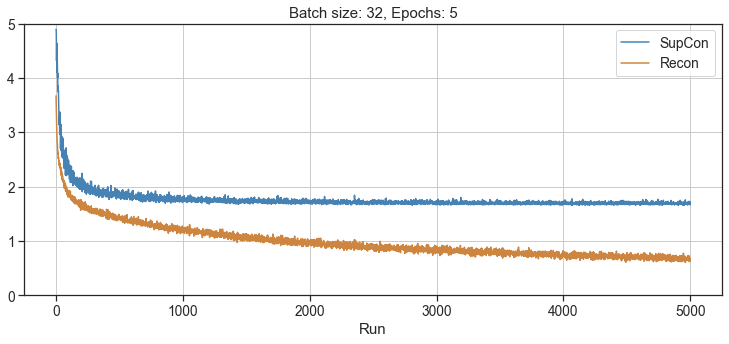

In [21]:
import seaborn as sns 
sns.set_theme(style='ticks',font_scale=1.25)
losses = pd.read_csv(f'results/training_logs/losses_{TAG}.csv',usecols=use_losses)

figsize=(12.5,5)
plt.figure(figsize=figsize)
for label,data in losses.iteritems():
    if label=='Recon':
        plt.plot(data, label=label, color="peru")
    elif label=='SupCon':
        plt.plot(data, label=label, color="steelblue")
plt.ylim(0,5)
plt.title(f'Batch size: {BS}, Epochs: {E}')
plt.grid(True)
plt.xlabel('Run')
plt.legend(loc='upper right')
plt.savefig(f'results/training_logs/loss_plot_{TAG}.png', bbox_inches='tight')
plt.show()

## UMAP a sample of training data.

In [22]:
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from matplotlib.offsetbox import OffsetImage,AnnotationBbox
import numpy as np
import copy

# anc_path = 'data/model_ready/01/test/anchor_smiles_ood.csv'
# aug_path = 'data/model_ready/01/test/augmented_smiles_ood.csv'
anc_path = 'data/model_ready/01/test/anchor_smiles.csv'
aug_path = 'data/model_ready/01/test/augmented_smiles.csv'

ds = ContraSeqDataset(anc_path, aug_path)
ds_arr = get_dataset_array(anc_path, aug_path)
anc_map = get_anc_map(ds_arr)
print(ds.tokens)

_df = copy.deepcopy(ds_arr)
print(len(_df))
_df.columns = ['Smiles','Atype','Label'] # [x[0].upper() + x[1:] for x in df.columns]

NUM_TO_EVAL = 1000

random.seed(666)
rand = random.sample(range(0,len(anc_map)),NUM_TO_EVAL)
rand_idc = np.concatenate([anc_map[x] for x in rand],axis=0)
print(rand_idc)

df = _df.iloc[rand_idc]
display(df)

from rdkit.Chem import PandasTools

PandasTools.AddMoleculeColumnToFrame(df,'Smiles','Mol',includeFingerprints=False)
df = df[["Smiles","Mol","Label","Atype"]]

#()+-1234567<=>BCFHILNOPRSX[]cnos
12000
[ 934 6670 6671 ... 3207 3208 3209]


,Smiles,Atype,Label
934,Cc1ccc(OC(CCCCn2ccnc2)c2ccc(Cl)cc2)cc1,Anc,934
4670,Cc1ccc(OC(CCCCn2ccnc2)c2ccc(Cl)c(C)c2)cc1,Aug,934
4671,Cc1ccc(OC(CCCCn2cnc(C)c2)c2ccc(Cl)cc2)cc1,Aug,934
4672,Cc1ccc(OC(CCCCn2ccnc2)c2ccc(Cl)cc2)c(C)c1,Aug,934
4673,Cc1ccc(OC(CC(C)CCn2ccnc2)c2ccc(Cl)cc2)cc1,Aug,934
...,...,...,...
1205,CS(=O)(=O)Nc1cccnc1Oc1ccc(N)cc1,Aug,241
1206,Cc1ccc(NS(C)(=O)=O)c(Oc2ccccc2)n1,Aug,241
1207,CN(c1cccnc1Oc1ccccc1)S(C)(=O)=O,Aug,241
1208,Cc1cccc(Oc2ncccc2NS(C)(=O)=O)c1,Aug,241


In [23]:
#()+-123456<=>CFHILNOPRSX[]cnos

### Get latent code from model.

In [24]:
normed = 'normed' if NORMED_LATENT else 'raw'
n_samp = NUM_TO_EVAL
tag_embedding = f'{TAG}_{normed}_{n_samp}anc_test'
print(tag_embedding)

2022041801_03_normed_1000anc_test


In [25]:
from tqdm.notebook import trange, tqdm
loader = DataLoader(ds, batch_size=1, sampler=rand_idc, num_workers=0, pin_memory=True)

latents = []
for samp in tqdm(loader, total=len(df)):
    for k,v in samp.items():
        if torch.is_tensor(v):
            samp[k] = v.to(device)
    latent, _ = model.forward(samp['seq'], samp['pad_mask'], 
                              samp['avg_mask'], samp['out_mask'], NORMED_LATENT)
    latent = latent.cpu().detach().numpy()
    latents.append(latent)
    
latents = np.stack(latents,axis=0)
latents = latents.squeeze(1)
print(latents.shape)

  0%|          | 0/6000 [00:00<?, ?it/s]

(6000, 32)


In [39]:
import umap.umap_ as umap
umapper = umap.UMAP(n_neighbors=32, min_dist=0.1, n_components=2, metric='euclidean')
embedding = umapper.fit_transform(latents)

df['x'] = embedding[:, 0]
df['y'] = embedding[:, 1]

In [40]:
coords = df[['x','y']]
coords.to_csv(f'results/embeddings/coords_{tag_embedding}_30neigh_mindist0pt1.csv')

In [9]:
from rdkit.Chem import rdMolDescriptors, Descriptors, Crippen
my_props = [(Descriptors.MolWt, "MolWt"),
            (Descriptors.HeavyAtomCount, "HeavyAtomCount"), 
            (Descriptors.FractionCSP3, "FractionCSP3"), 
            (Descriptors.TPSA, "TPSA"), 
            (Descriptors.NumHAcceptors, "NumHAcceptors"), 
            (Descriptors.NumHDonors, "NumHDonors"), 
            (Descriptors.NumRotatableBonds, "NumRotatableBonds"), 
            (Crippen.MolLogP, "MolLogP"),
           ]

my_props_names = [x[1] for x in my_props]

for descriptor, name in my_props:
    props = [descriptor(m) for m in df.Mol] 
    df[name] = props

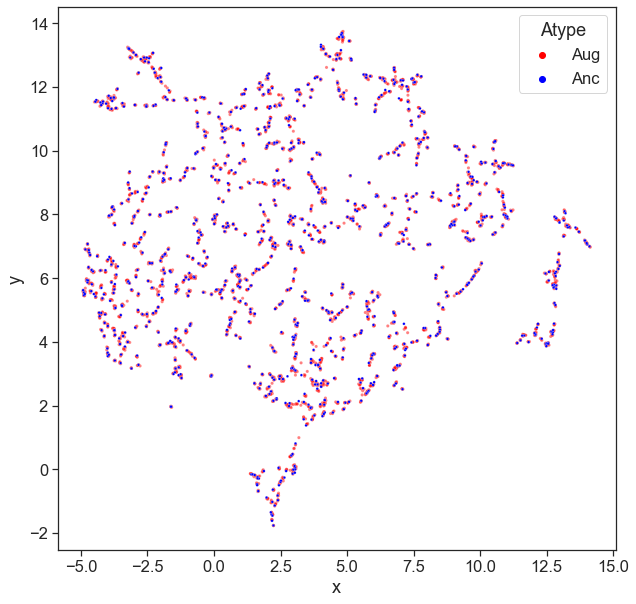

In [41]:
import seaborn as sns 
sns.set_theme(style='ticks',font_scale=1.5)

plt.figure(figsize=(10,10))

sns.scatterplot(data=df[df['Atype']=='Aug'], x='x', y='y', hue='Atype', 
                alpha=0.5, s=10, palette={'Aug':'red'})
sns.scatterplot(data=df[df['Atype']=='Anc'], x='x', y='y', hue='Atype', 
                alpha=1., s=7, palette={'Anc':'blue'})
plt.savefig(f'results/embeddings/umap_{tag_embedding}_30neigh_mindist0pt1.png', bbox_inches='tight')
plt.show()

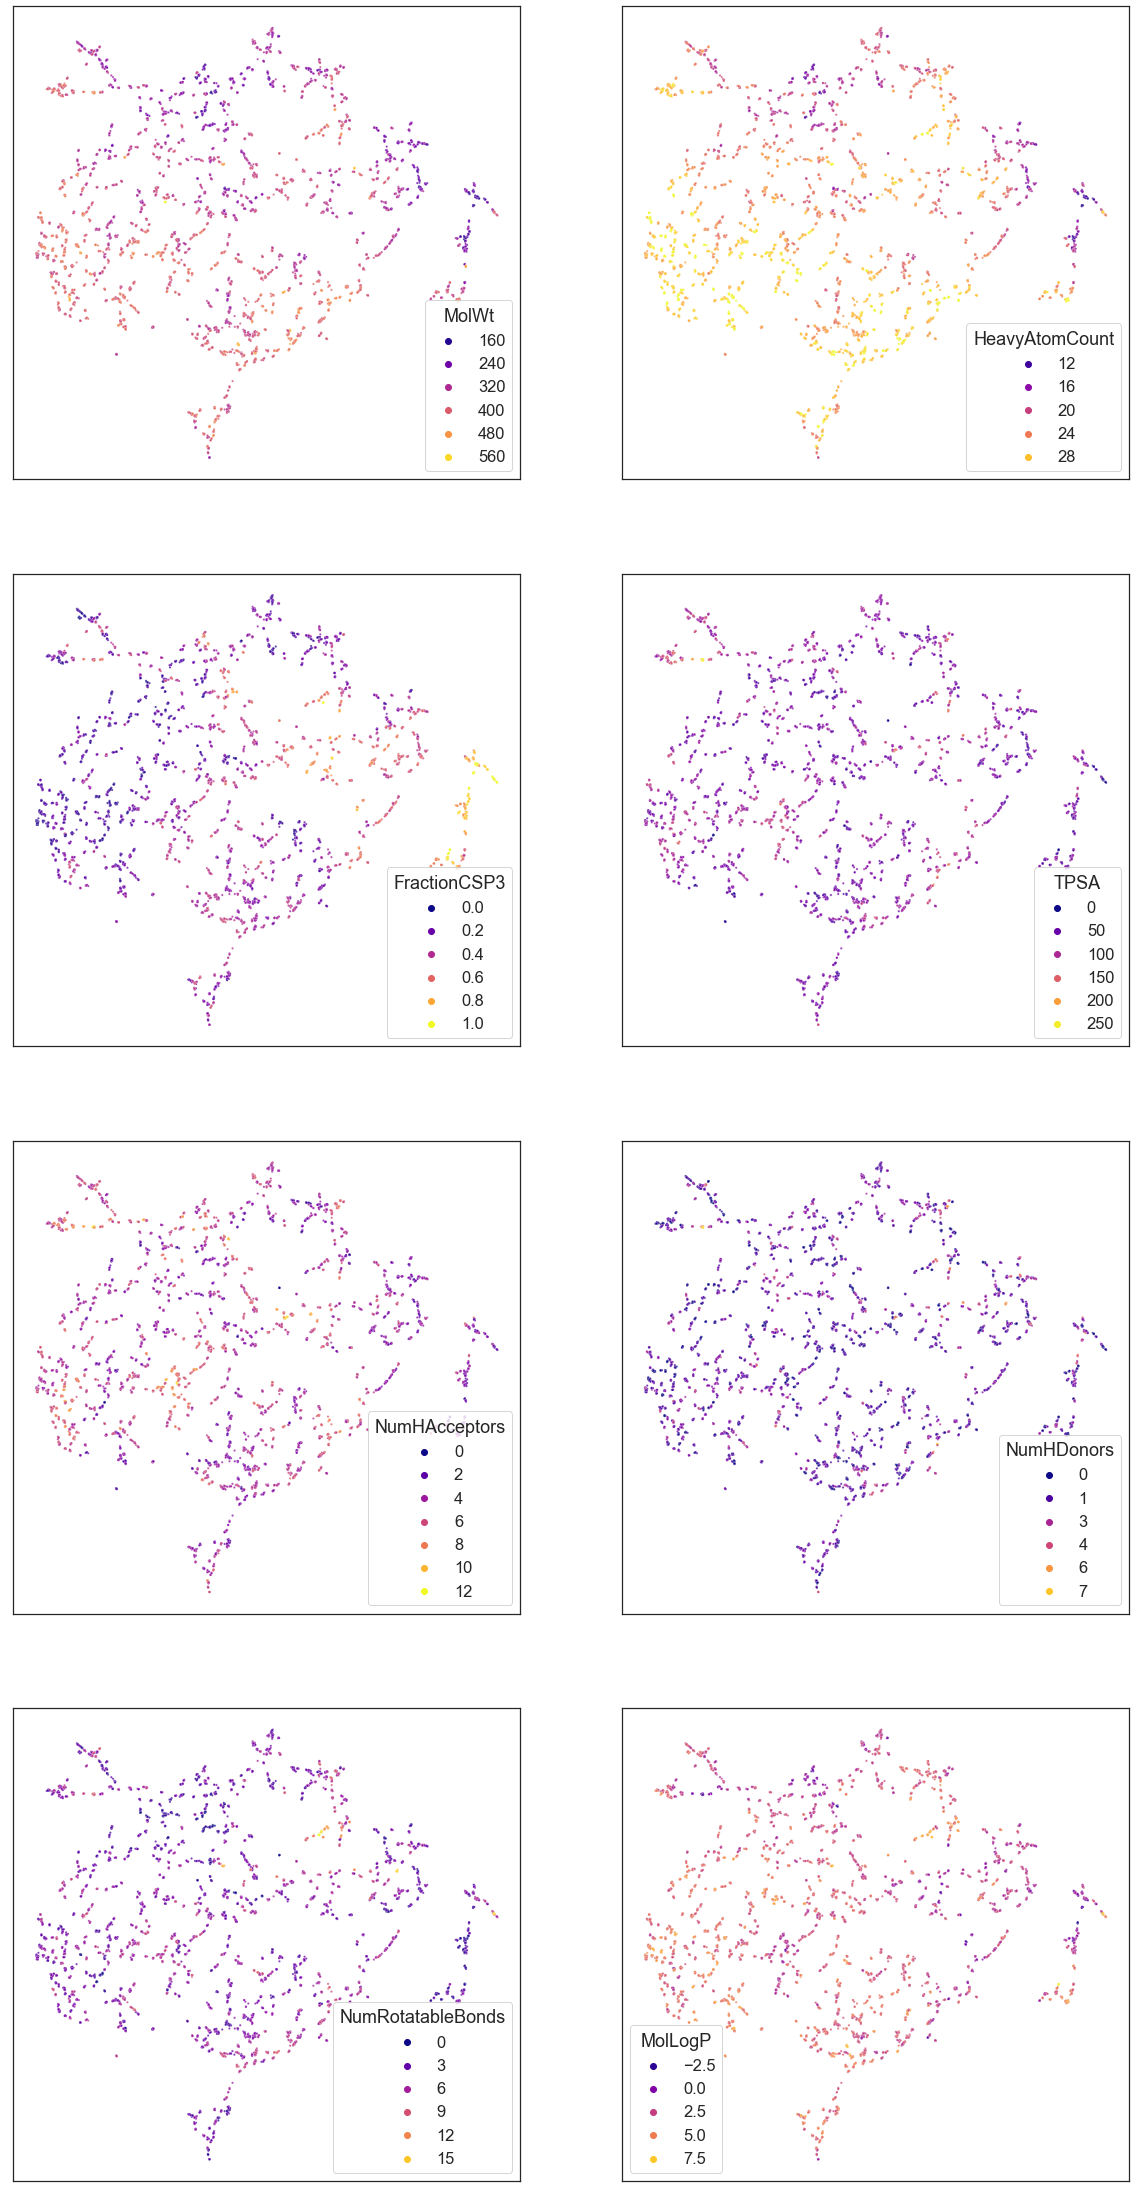

In [43]:
fig, axs = plt.subplots(ncols=2,nrows=4,figsize=(20,40)) 
for i,prop in enumerate(my_props_names):
    row = i//2
    col = i%2
    fig = sns.scatterplot(data=df, x='x', y='y', hue=prop,
                          alpha=0.75, s=5, palette='plasma', ax=axs[row][col]) 
    fig.axes.get_xaxis().set_visible(False)
    fig.axes.get_yaxis().set_visible(False) 
display()

In [44]:
%matplotlib inline
import plotly.graph_objs as go

from ipywidgets import Image, Layout, HBox, VBox
from rdkit.Chem import Draw
import PIL

import ipywidgets as widgets
import io

# Assemble all the traces.
trace_anchors = (go.Scattergl(x=df[df.Atype=='Anc']['x'], 
                           y=df[df.Atype=='Anc']['y'], 
                           name='Anchors',
                           marker=dict(size=3, opacity=0.75, color='blue'),
                           hoverinfo='text',
                           text=df[df.Atype=='Anc']['Smiles'],
                           mode='markers'))
trace_augmentations = (go.Scattergl(x=df[df.Atype=='Aug']['x'], 
                           y=df[df.Atype=='Aug']['y'], 
                           name='Augmentations',
                           marker=dict(size=3, opacity=0.75, color='red'), #chartreuse
                           hoverinfo='text',
                           text=df[df.Atype=='Aug']['Smiles'],
                           mode='markers'))
data = [trace_augmentations, trace_anchors, ]

# Make figure.
fig = go.FigureWidget(data=data)
# fig.layout.hovermode = 'closest'
fig.update_layout(template='simple_white', autosize=False, height=512)
fig.update_yaxes(scaleanchor = "x", scaleratio = 1.)

# Show-mol-on-hover function.
# img = open('white.png','rb').read()
img = PIL.Image.new('1', (256, 256)).tobytes()
image_widget = Image(value=img)

def hover_fn(trace, points, state):
    
    if points.point_inds:
        if trace['name']=='Anchors':
            my_df = df[df.Atype=='Anc']
        elif trace['name']=='Augmentations':
            my_df = df[df.Atype=='Aug']
            
        idx = points.point_inds[0]
        datum = my_df.iloc[idx]
        mol = datum.Mol

        img = Draw.MolToImage(mol,size=(256, 512))  ### to make mol image smaller, alter first dim. 
        imgByteArr = io.BytesIO()
        img.save(imgByteArr, format='PNG')
        imgByteArr = imgByteArr.getvalue()
        image_widget.value = imgByteArr

for trace_num in range(len(fig.data)):
    fig.data[trace_num].on_hover(hover_fn)  
HBox([HBox([image_widget]),fig])